## 数据读取和可视化

## 数据集下载地址：https://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes

### 数据读取

In [1]:
from pathlib import Path
import os, sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/hsi_learning').is_dir() and (p/'dataset').is_dir()), None)
if ROOT is None: raise RuntimeError('Start inside HSI-Learning')
os.chdir(ROOT)
sys.path.insert(0,str(ROOT/'src'))
sys.path.insert(0,str(ROOT/'scripts'))
print('Project root:',ROOT)

from IPython import get_ipython
get_ipython().run_line_magic('matplotlib','inline')
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')


Project root: D:\JupyterWorkSpace\HSI-Learning


In [2]:
# 导包
from scipy.io import loadmat
import numpy as np

In [3]:
# 从文件加载数据
indian_pines = loadmat('./dataset/Indian_pines_corrected.mat')

In [4]:
print(type(indian_pines))

<class 'dict'>


In [5]:
print(indian_pines.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_corrected'])


In [6]:
# 根据字典的key获取数据集里面的内容
indian_pines = indian_pines['indian_pines_corrected']

In [7]:
# 打印原始数据形状
print(indian_pines.shape)

(145, 145, 200)


In [8]:
# 同样的方式读取数据标签
indian_pines_gt = loadmat('./dataset/Indian_pines_gt.mat')
print(indian_pines_gt.keys())

dict_keys(['__header__', '__version__', '__globals__', 'indian_pines_gt'])


In [9]:
indian_pines_gt = indian_pines_gt['indian_pines_gt']

In [10]:
# 查看标签内容
np.unique(indian_pines_gt)
# 不同的数字对应不同的类别

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
      dtype=uint8)

### 数据可视化

In [11]:
# 将数据赋值给X,Y方便后期操作使用

In [12]:
X = indian_pines
y = indian_pines_gt
print(f"X_shape:{X.shape},Y_shape:{y.shape}")

X_shape:(145, 145, 200),Y_shape:(145, 145)


### 直观展示

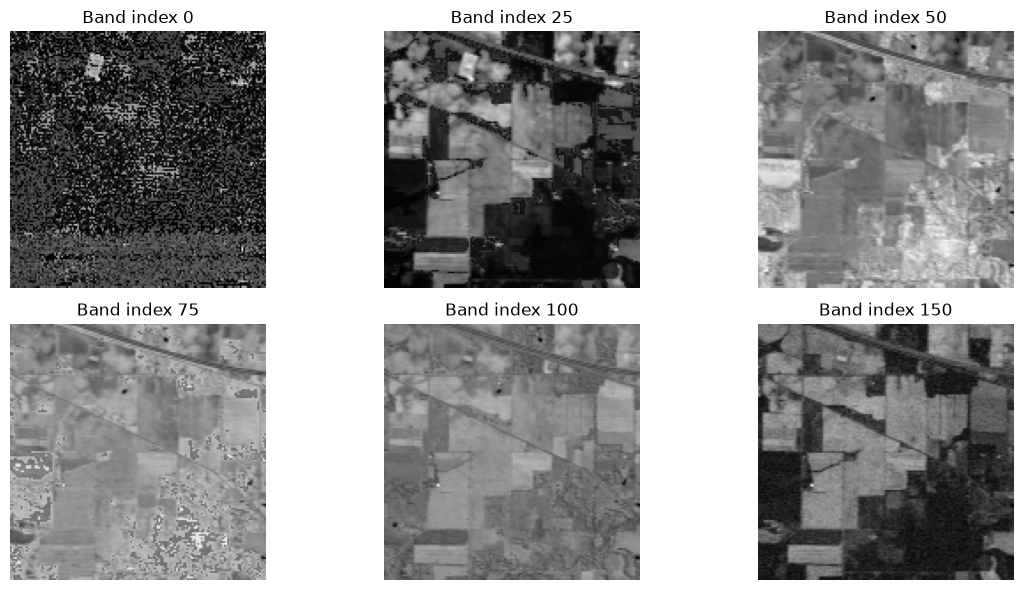

In [13]:
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(12,6))
for i,q in enumerate([0,25,50,75,100,150],1):
    ax=fig.add_subplot(2,3,i); ax.imshow(X[:,:,q],cmap='gray'); ax.axis('off'); ax.set_title(f'Band index {q}')
plt.tight_layout(); plt.show()


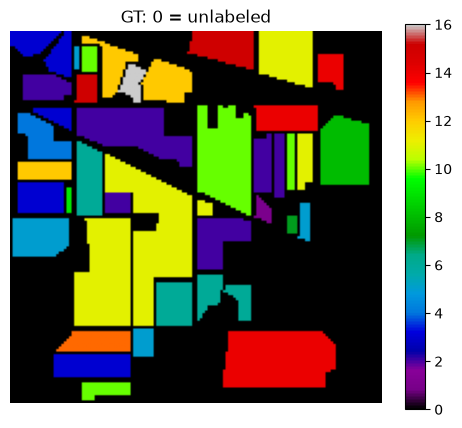

In [14]:
plt.figure(figsize=(6,5)); plt.imshow(y,cmap='nipy_spectral',vmin=0,vmax=16); plt.title('GT: 0 = unlabeled'); plt.colorbar(); plt.axis('off'); plt.show()


In [15]:
# 使用python3D可视化,需要安装前置的包也可以使用高光谱软件，这里不在演示

In [16]:
# Optional desktop 3D viewer. Keep False for portable classroom execution.
RUN_DESKTOP_GUI=False
if RUN_DESKTOP_GUI:
    import spectral, wx
    app=wx.App()
    spectral.settings.WX_GL_DEPTH_SIZE=16
    spectral.view_cube(X,bands=[29,19,9])
    app.MainLoop()
else:
    print('Desktop wx/OpenGL viewer skipped; static band and spectral figures above are portable.')


Desktop wx/OpenGL viewer skipped; static band and spectral figures above are portable.


In [17]:
##################################################################

## 光谱对照
同类像元也有差异；不同类曲线可能重叠。横轴无波长元数据时使用波段索引。显示拉伸、标准化与PCA是不同操作。

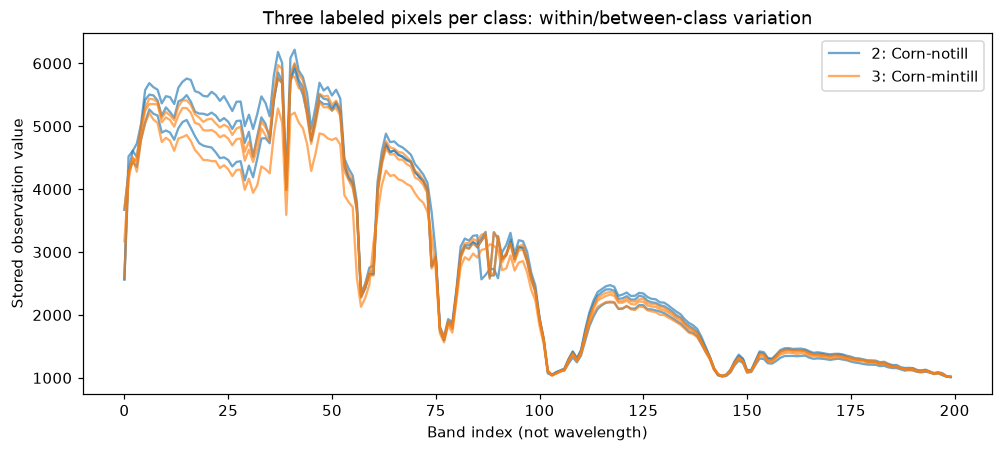

In [18]:
from hsi_learning.data import load_hsi_dataset
from hsi_learning.teaching_plots import style
style()
cube,gt,names=load_hsi_dataset('IP',ROOT/'dataset')
fig,ax=plt.subplots(figsize=(9,4),layout='constrained')
for class_id,color in [(2,'tab:blue'),(3,'tab:orange')]:
    ids=np.flatnonzero(gt.ravel()==class_id)[:3]
    for j,pixel in enumerate(ids):
        ax.plot(cube.reshape(-1,200)[pixel],color=color,alpha=.65,label=f'{class_id}: {names[class_id-1]}' if j==0 else None)
ax.set_xlabel('Band index (not wavelength)'); ax.set_ylabel('Stored observation value')
ax.set_title('Three labeled pixels per class: within/between-class variation'); ax.legend(); plt.show()
